Confusion Matrix:
[[930   0]
 [ 70   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       930
           1       0.00      0.00      0.00        70

    accuracy                           0.93      1000
   macro avg       0.47      0.50      0.48      1000
weighted avg       0.86      0.93      0.90      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


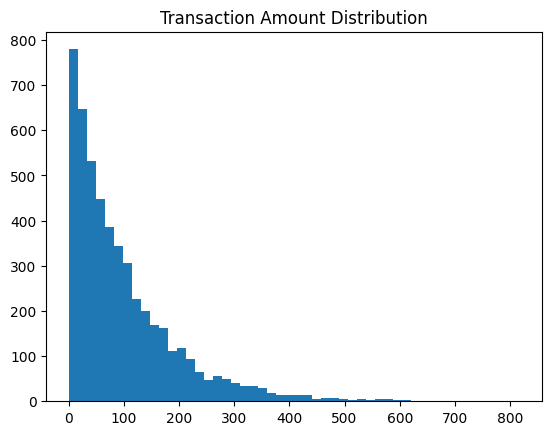

In [1]:
# ==================================
# FRAUD DETECTION MODEL
# ==================================

!pip install pandas numpy matplotlib scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

# Generate dataset
n = 5000

df = pd.DataFrame({
    "Amount": np.random.exponential(100, n),
    "Transaction_Time": np.random.randint(0, 86400, n),
    "Location_Risk": np.random.randint(0, 5, n),
    "Device_Risk": np.random.randint(0, 5, n),
    "Fraud": np.random.choice([0,1], n, p=[0.95,0.05])
})

df.to_csv("fraud_data.csv", index=False)

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

plt.figure()
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()